In [1]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
import ast

In [2]:
df= pd.read_csv("C:/Users/85290/OneDrive - The Chinese University of Hong Kong/stat4012/hotel_reviews_with_topics_indexed.csv")
# Check if the 'review_indexed_padded' column is a string or list
def safe_convert(value):
    try:
        # If the value is a string representation of a list, convert it to a list
        if isinstance(value, str):
            return ast.literal_eval(value)
        elif isinstance(value, list):
            return value
        else:
            return None  # Return None if it's neither a string nor a list
    except Exception as e:
        print(f"Error converting value: {value}, Error: {e}")
        return None

# Apply the conversion function
df['review_indexed_padded'] = df['review_indexed_padded'].apply(safe_convert)
# Clean up any unwanted characters (e.g., extra spaces, quotes)
df['review_indexed_padded'] = df['review_indexed_padded'].apply(lambda x: str(x).strip())

# Now try to safely convert the string representation of a list to an actual list
df['review_indexed_padded'] = df['review_indexed_padded'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad the sequences (you can choose a max length, e.g., 100)
max_sequence_length = 200  # Choose a max length based on your data

X_reviews_padded = pad_sequences(df['review_indexed_padded'].tolist(), maxlen=max_sequence_length, padding='post')
from sklearn.preprocessing import LabelEncoder
df['Rating'] = LabelEncoder().fit_transform(df['Rating'])

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Number of classes in your target
num_classes = len(df['Rating'].unique())  # make sure your labels are 0-indexed if using sparse

# Pad the sequences
X_reviews_padded = pad_sequences(df['review_indexed_padded'].tolist(), padding='post', maxlen=200)

# Calculate vocab size
vocab_size = max([max(seq) for seq in df['review_indexed_padded'].tolist()]) + 1

# Prepare target labels
# Option 1: One-hot encoding (use categorical_crossentropy)
y = to_categorical(df['Rating'].values)

# Option 2: If you prefer sparse_categorical_crossentropy, skip one-hot:
# y = df['Rating'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reviews_padded, y, test_size=0.2, random_state=42)

# Build the model
model = Sequential()
model.add(Input(shape=(200,)))
model.add(Embedding(input_dim=vocab_size, output_dim=128))
model.add(Dropout(0.3))
model.add(LSTM(64, return_sequences=False, dropout=0.2))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Compile the model
model.compile(
    loss='categorical_crossentropy',       # or 'sparse_categorical_crossentropy' if y is not one-hot
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Train
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Predicted class labels
y_pred_classes = y_pred_probs.argmax(axis=1)

Epoch 1/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 36s 68ms/step - accuracy: 0.3914 - loss: 1.4416 - val_accuracy: 0.4354 - val_loss: 1.3556
Epoch 2/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.4516 - loss: 1.3592 - val_accuracy: 0.4418 - val_loss: 1.3679
Epoch 3/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 60s 118ms/step - accuracy: 0.4602 - loss: 1.3270 - val_accuracy: 0.3056 - val_loss: 1.4170
Epoch 4/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 64s 126ms/step - accuracy: 0.4795 - loss: 1.2926 - val_accuracy: 0.4393 - val_loss: 1.4067
Epoch 5/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.4873 - loss: 1.2690 - val_accuracy: 0.4432 - val_loss: 1.4378
Epoch 6/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.4996 - loss: 1.2462 - val_accuracy: 0.4427 - val_loss: 1.4577
Epoch 7/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.5027 - loss: 1.2356 - val_accuracy: 0.4373 - val_loss: 1.7219
Epoch 8/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.5034 - loss: 1.2348 

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy: 0.4450
Precision (Macro): 0.3493
Recall (Macro): 0.2190
F1 Score (Macro): 0.1699


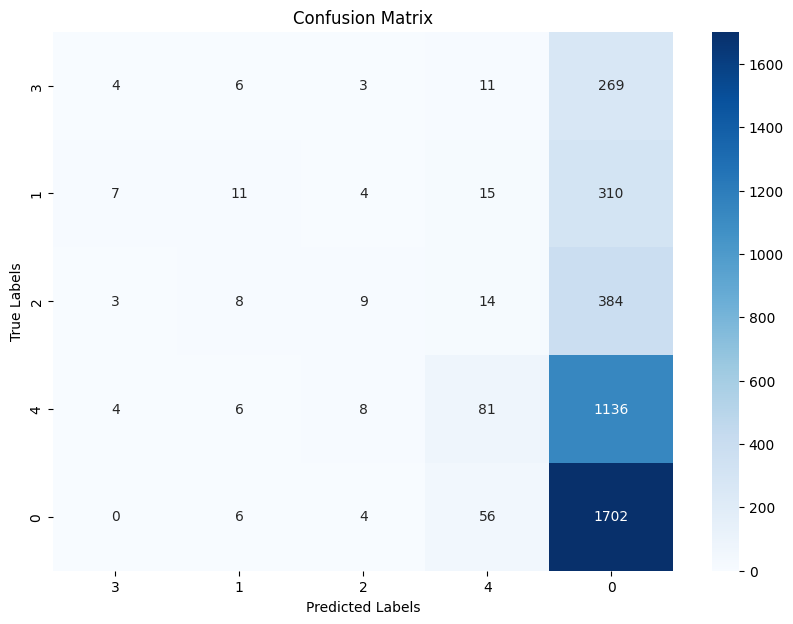


Per-Class Metrics:
Class 0:
  Precision: 0.2222
  Recall: 0.0137
  F1 Score: 0.0257
Class 1:
  Precision: 0.2973
  Recall: 0.0317
  F1 Score: 0.0573
Class 2:
  Precision: 0.3214
  Recall: 0.0215
  F1 Score: 0.0404
Class 3:
  Precision: 0.4576
  Recall: 0.0656
  F1 Score: 0.1147
Class 4:
  Precision: 0.4478
  Recall: 0.9627
  F1 Score: 0.6112


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict the class labels
y_pred_classes = model.predict(X_test).argmax(axis=1)  # Get predicted class labels

# Actual class labels
y_true = y_test.argmax(axis=1)  # If y_test is one-hot encoded, convert to integer labels

# 1. Accuracy Score
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 2. Precision, Recall, and F1 Score (macro averaged)
precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

# 3. Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Visualizing confusion matrix using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=df['Rating'].unique(), yticklabels=df['Rating'].unique())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# If you'd like per-class metrics (for precision, recall, f1)
print("\nPer-Class Metrics:")
for i in range(num_classes):
    print(f"Class {i}:")
    print(f"  Precision: {precision_score(y_true, y_pred_classes, average=None)[i]:.4f}")
    print(f"  Recall: {recall_score(y_true, y_pred_classes, average=None)[i]:.4f}")
    print(f"  F1 Score: {f1_score(y_true, y_pred_classes, average=None)[i]:.4f}")



Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.01      0.03       293
           1       0.30      0.03      0.06       347
           2       0.32      0.02      0.04       418
           3       0.46      0.07      0.11      1235
           4       0.45      0.96      0.61      1768

    accuracy                           0.44      4061
   macro avg       0.35      0.22      0.17      4061
weighted avg       0.41      0.44      0.31      4061

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


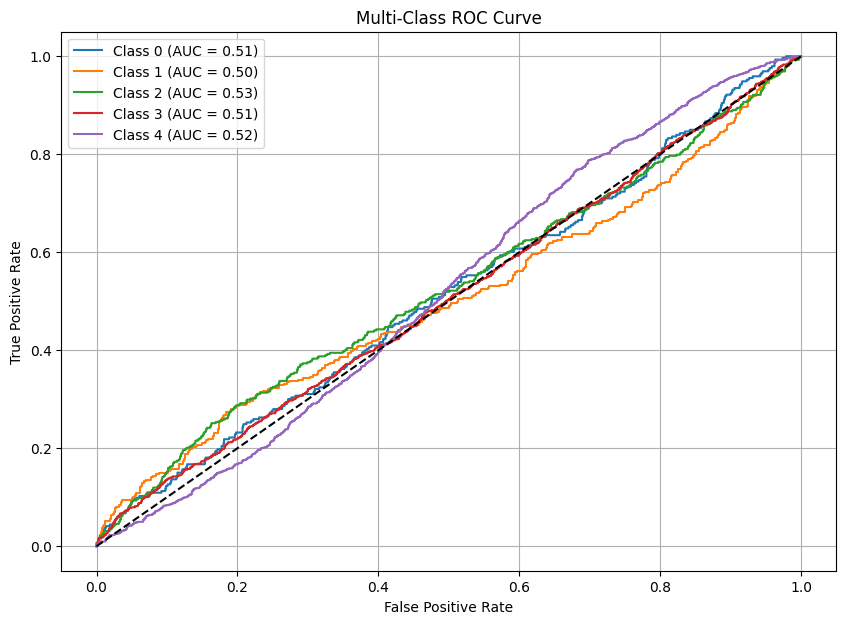

In [5]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# ----------------------------
# Classification Report
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))

# ----------------------------
# ROC Curve (One-vs-Rest)
# ----------------------------

# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Predict class probabilities (already done if you saved earlier)
y_pred_probs = model.predict(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.title('Multi-Class ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()
